In [12]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.nca import NeuralCAv1, NeuralCAv2

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

from ncpu.loss import loss_mse_whole_seq

model_path = None

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())   # Should be True
print(torch.cuda.device_count())   # Should show 1
print(torch.cuda.get_device_name(0))  # Should show "NVIDIA GeForce GTX 1080 Ti"

2.7.1+cu118
11.8
True
1
NVIDIA GeForce GTX 1080 Ti


In [14]:

from ncpu.config import TINY_AND_FARAWAY_TRAINING_CONFIG


LEARNING_RATE = 0.001
BATCH_SIZE = 8
GAUSSIAN_NOISE = 0.2
STEPS = 2_500

In [15]:
from ncpu.dataset import NCPUDataset 
dataset = NCPUDataset(TINY_AND_FARAWAY_TRAINING_CONFIG)


# Learn GATE Logic

In [20]:
from ncpu.trainer import NCPUTrainer

nca = NeuralCAv1(
    channels = 8,
    hidden_channels = 128,
    fire_rate = 0.99,
    alive_masking_flag = True,
    zero_initialization = True,
)

# nca = NeuralCAv2(
#     channels = 8,
#     hidden_channels=[128],
#     fire_rate = 0.99,
#     alive_threshold=0.1,
#     zero_initialization = True,
#     kernel_size=5,
#     read_only_dims=[-1]
# )

trainer = NCPUTrainer(
    nca,
    dataset.get_dataloader(batch_size=BATCH_SIZE),
    lr=LEARNING_RATE,
    gaussian_noise=GAUSSIAN_NOISE,
)
trainer.sanity_check()
trainer.save_checkpoint()

Sanity check...
1:  torch.Size([2, 24, 66, 66]) torch.Size([2, 8, 64, 64])
2:  torch.Size([2, 8, 66, 66]) torch.Size([2, 8, 66, 66])
torch.Size([2, 1, 66, 66]) torch.Size([2, 1, 66, 66])
3:  torch.Size([2, 8, 66, 66])
4:  torch.Size([2, 8, 66, 66])


RuntimeError: The size of tensor a (64) must match the size of tensor b (66) at non-singleton dimension 3

In [18]:
stop_loss = 0.0001
pbar = tqdm(range(STEPS))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80), loss = loss_mse_whole_seq)
    loss = info["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

trainer.save_checkpoint()

  0%|          | 0/2500 [00:00<?, ?it/s]

1:  torch.Size([8, 24, 66, 66]) torch.Size([8, 8, 64, 64])
2:  torch.Size([8, 8, 66, 66]) torch.Size([8, 8, 66, 66])
torch.Size([8, 1, 68, 68]) torch.Size([8, 1, 68, 68])


RuntimeError: The size of tensor a (66) must match the size of tensor b (68) at non-singleton dimension 3

# Learning Information Propagation

In [12]:
# load seed model
# trainer.load_checkpoint()

RuntimeError: Error(s) in loading state_dict for NeuralCAv1:
	Missing key(s) in state_dict: "all_filters_batch", "rule.0.weight", "rule.0.bias", "rule.2.weight". 
	Unexpected key(s) in state_dict: "perception.all_filters_batch", "read_only_channels.read_only_mask", "rule.rule.0.weight", "rule.rule.0.bias", "rule.rule.2.weight". 

loss=0.009291:   8%|7         | 600/8000 [12:52<2:17:43,  1.12s/it]

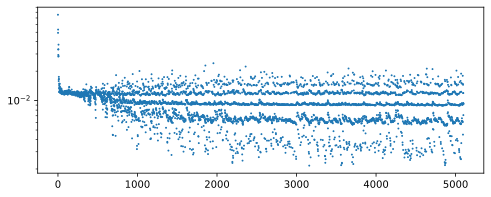

inp    : (8, 64, 64) torch.float32, min=-1.75, max=1.58, mean=-0.00, std=0.25
out    : (8, 64, 64) torch.float32, min=-1.00, max=0.99, mean=-0.01, std=0.11
nca_out: (8, 64, 64) torch.float32, min=-0.56, max=0.03, mean=-0.01, std=0.05
rollout.shape: torch.Size([8, 70, 8, 64, 64]) to_show: 8
display size: (64, 64)


,,,,,,,
,,,,,,,
,,,,,,,

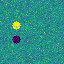
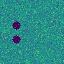
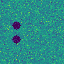
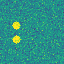
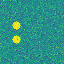
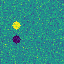
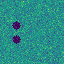
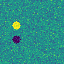
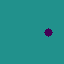
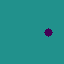
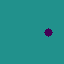
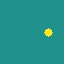
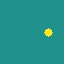
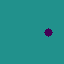
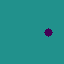
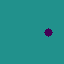
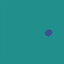
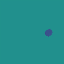
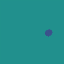
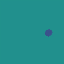
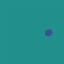
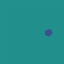
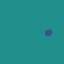
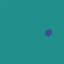

channels: [0, 1, 2, 3, 4, 5, 6, 7]


#0:0,#1:0,#2:0,#3:0,#4:0,#5:0,#6:0,#7:0

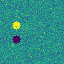
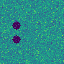
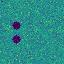
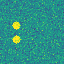
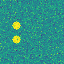
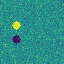
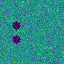
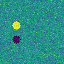

#0:1,#1:1,#2:1,#3:1,#4:1,#5:1,#6:1,#7:1

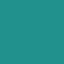
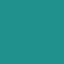
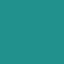
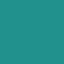
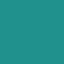
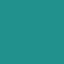
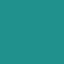
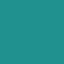

#0:2,#1:2,#2:2,#3:2,#4:2,#5:2,#6:2,#7:2

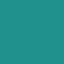
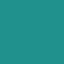
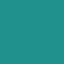
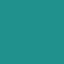
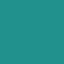
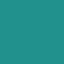
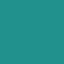
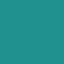

#0:3,#1:3,#2:3,#3:3,#4:3,#5:3,#6:3,#7:3

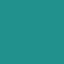
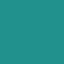
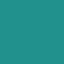
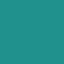
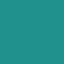
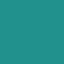
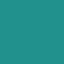
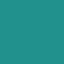

#0:4,#1:4,#2:4,#3:4,#4:4,#5:4,#6:4,#7:4

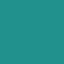
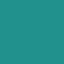
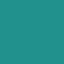
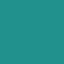
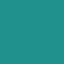
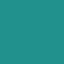
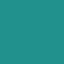
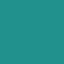

#0:5,#1:5,#2:5,#3:5,#4:5,#5:5,#6:5,#7:5

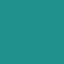
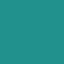
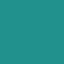
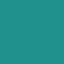
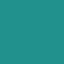
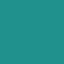
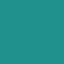
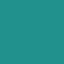

#0:6,#1:6,#2:6,#3:6,#4:6,#5:6,#6:6,#7:6

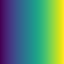
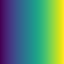
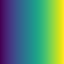
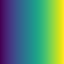
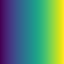
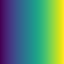
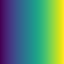
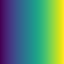

#0:7,#1:7,#2:7,#3:7,#4:7,#5:7,#6:7,#7:7

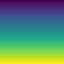
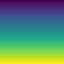
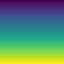
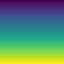
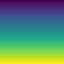
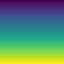
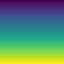
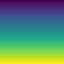

------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
stop_loss = 0.0001
pbar = tqdm(range(STEPS*4))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80), loss=loss_mse_whole_seq)
    loss = info["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

trainer.save_checkpoint()

In [ ]:

trainer.save_checkpoint("AND_propagated_5.pth", timestamp=False)

In [9]:
# load seed model
trainer.load_checkpoint("ncpu_AND_propagated_5.pth")

In [ ]:
stop_loss = 0.0001
STEPS = 2000
pbar = tqdm(range(STEPS*10))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

trainer.save_checkpoint("AND_checkpoint_final.pth", timestamp=False)

In [ ]:
stop_loss = 0.0001
pbar = tqdm(range(1))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    clear_output(wait=False)
    display(pbar.container)

    trainer.display_optim_step(info)
